# Quick start
The `batcamp` package builds an [octree](https://en.wikipedia.org/wiki/Octree) over known mesh cell geometry, and uses using that octree for fast resampling and related spatial queries on scientific simulation data. The library is written to support fast analysis of [SWMF/BATSRUS](https://clasp.engin.umich.edu/research/theory-computational-methods/space-weather-modeling-framework/) data for which only point and hexahedron information is stored. `batcamp` uses the hexahedral "leaf cells" to reconstruct a full, searchable octree structure.

`batcamp` provides an octree based interpolator which outperforms the `scipy` workhorse [`LinearNDInterpolator`](https://scipy.github.io/devdocs/reference/generated/scipy.interpolate.LinearNDInterpolator.html), as it makes full use of the octree structure of the data.

## Local example
A sample BATSRUS file ships with the repository. It contains point and leaf cell data. We read it with the `batread` module.

In [46]:
from batread import Dataset

ds = Dataset.from_file("../sample_data/3d__var_1_n00000000.plt")
print(ds)

Title:     'BATSRUS: 3D Data, 2011/02/16 17:26:00.000'
Zone:      '3D   N=0000000'
Variables: 24
Shape:     (12800, 24)
Variables: ['X [R]', 'Y [R]', 'Z [R]', 'Rho [g/cm^3]', 'U_x [km/s]', 'U_y [km/s]', 'U_z [km/s]', 'ti [K]', 'te [K]', 'B_x [Gauss]', 'B_y [Gauss]', 'B_z [Gauss]', 'I01 [erg/cm^3]', 'I02 [erg/cm^3]', 'P [dyne/cm^2]', 'pe [dyne/cm^2]', 'E [erg/cm^3]', 'ehot [erg/cm^3]', 'qrad J/m^3/s', 'qheat J/m^3/s', 'refl 1/s', 'J_x [`mA/m^2]', 'J_y [`mA/m^2]', 'J_z [`mA/m^2]'].


The octree can now be built using the point and corner data. The $xyz$ coordinates comprise the first three variables, and the rest are field values. The corner_ids index into the point data; each cell comprises eight corners.

In [47]:
points_xyz = ds.points[..., :3]
points_data = ds.points[..., 3:]
print(f"Point coordinates: {points_xyz.shape=}")
print(f"Point data: {points_data.shape=}")
corner_ids = ds.corners
print(f"Corner IDs: {corner_ids.shape=}")

Point coordinates: points_xyz.shape=(12800, 3)
Point data: points_data.shape=(12800, 21)
Corner IDs: corner_ids.shape=(12288, 8)


Here we show how the octree is built from points and corner IDs. There is also a convenience method that builds the octree directly from the `ds` (shown later).

In [48]:
from batcamp import Octree
octree = Octree(points_xyz, corner_ids)
print(octree)

Octree(tree_coord=rpa, root_shape=(3, 2, 4), leaf_shape=(24, 16, 32), leaf_cells=12288, runtime_cells=14040, levels=3..3)


With the octree reconstructed, it can be fed to the octree interpolator.

In [49]:
from batcamp import OctreeInterpolator
interp = OctreeInterpolator(octree, points_data)
print(interp)

OctreeInterpolator(tree_coord=rpa, n_points=12800, n_cells=12288, n_components=21)


A simple first query is a Cartesian slice through `z = 0`. The interpolator accepts grid-shaped `X`, `Y`, `Z` arrays directly, so the plotting code can stay close to the mathematics.

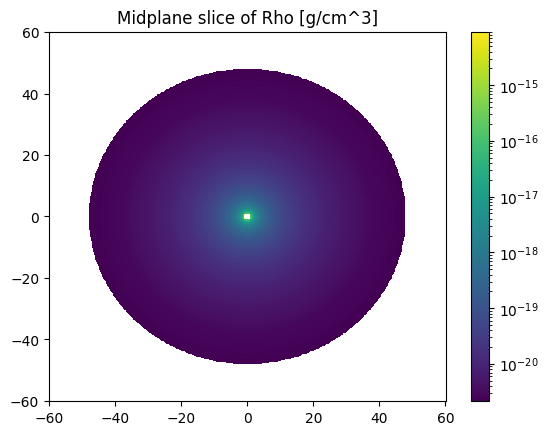

In [50]:
import numpy as np
import matplotlib.pyplot as plt
X, Y = np.meshgrid(np.linspace(-60, 60, 512), np.linspace(-60, 60, 512))
Z = np.zeros_like(X)
data = interp(X, Y, Z)

fig, ax = plt.subplots()
pcm = ax.pcolormesh(X, Y, data[..., 0], norm="log")
fig.colorbar(pcm, ax=ax)
ax.set_title("Midplane slice of Rho [g/cm^3]")
plt.show()

## Two larger examples
The next examples use one solar corona file and one inner heliosphere file from a larger archive. The data files are downloaded and cached with the `pooch` package.

In [51]:
import pooch

sc_file, ih_file = pooch.retrieve(
    url = "https://zenodo.org/records/7110555/files/run-Sun-G2211.tar.gz",
    known_hash="c31a32aab08cc20d5b643bba734fd7220e6b369e691f55f88a3a08cc5b2a2136",
    progressbar=True,
    processor=pooch.Untar(
        members = [
            "run-Sun-G2211/SC/IO2/3d__var_4_n00044000.plt",
            "run-Sun-G2211/IH/IO2/3d__var_4_n00005000.plt",
        ]
    ),
)

print(f"{sc_file=}")
print(f"{ih_file=}") 

sc_file='/Users/dagfev/Library/Caches/pooch/8c62a596be9356ac52956bdee5198bec-run-Sun-G2211.tar.gz.untar/run-Sun-G2211/SC/IO2/3d__var_4_n00044000.plt'
ih_file='/Users/dagfev/Library/Caches/pooch/8c62a596be9356ac52956bdee5198bec-run-Sun-G2211.tar.gz.untar/run-Sun-G2211/IH/IO2/3d__var_4_n00005000.plt'


## Solar corona (SC)
The solar-corona dataset uses a spherically structured octree; this is, however, transparent to the user.

In [52]:
sc_ds = Dataset.from_file(sc_file)
print(sc_ds)

Title:     'BATSRUS: 3D Data, 2011/02/16 17:26:00.000'
Zone:      '3D   N=0044000'
Variables: 24
Shape:     (532480, 24)
Variables: ['X [R]', 'Y [R]', 'Z [R]', 'Rho [g/cm^3]', 'U_x [km/s]', 'U_y [km/s]', 'U_z [km/s]', 'ti [K]', 'te [K]', 'B_x [Gauss]', 'B_y [Gauss]', 'B_z [Gauss]', 'I01 [erg/cm^3]', 'I02 [erg/cm^3]', 'P [dyne/cm^2]', 'pe [dyne/cm^2]', 'E [erg/cm^3]', 'ehot [erg/cm^3]', 'qrad J/m^3/s', 'qheat J/m^3/s', 'refl 1/s', 'J_x [`mA/m^2]', 'J_y [`mA/m^2]', 'J_z [`mA/m^2]'].


In [53]:
sc_octree = Octree.from_ds(sc_ds)  # This is a convenience method that does the same thing as Octree(point_xyz, corner_ids)
print(sc_octree)

Octree(tree_coord=rpa, root_shape=(1, 1, 2), leaf_shape=(64, 64, 128), leaf_cells=524288, runtime_cells=599186, levels=6..6)


In [54]:
sc_interp = OctreeInterpolator(sc_octree, sc_ds["Rho [g/cm^3]"])  # Named indexing is used on the ds object.
print(sc_interp)

OctreeInterpolator(tree_coord=rpa, n_points=532480, n_cells=524288, n_components=1)


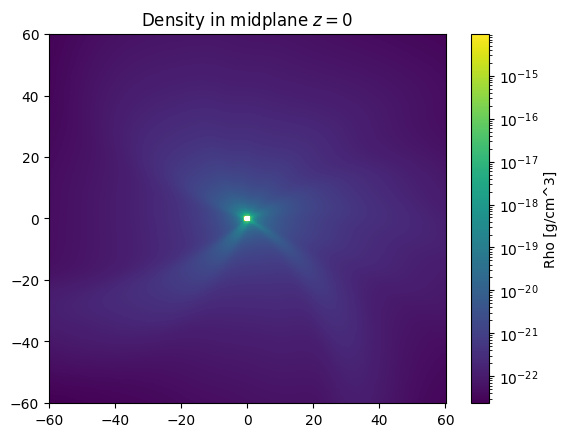

In [67]:
sc_X, sc_Y = np.meshgrid(np.linspace(-60, 60, 512), np.linspace(-60, 60, 512))
sc_Z = np.zeros_like(sc_X)
sc_rho = sc_interp(sc_X, sc_Y, sc_Z)

fig, ax = plt.subplots()
pcm = ax.pcolormesh(sc_X, sc_Y, sc_rho, norm="log")
fig.colorbar(pcm, ax=ax).set_label("Rho [g/cm^3]")
ax.set_title("Density in midplane $z=0$")

plt.show()

## Inner heliosphere (IH)
The inner-heliosphere file is a cartesian octree.

In [56]:
ih_ds = Dataset.from_file(ih_file)
print(ih_ds)

Title:     'BATSRUS: 3D Data, 2011/02/16 17:26:00.000'
Zone:      '3D   N=0005000'
Variables: 24
Shape:     (4139545, 24)
Variables: ['X [R]', 'Y [R]', 'Z [R]', 'Rho [g/cm^3]', 'U_x [km/s]', 'U_y [km/s]', 'U_z [km/s]', 'ti [K]', 'te [K]', 'B_x [Gauss]', 'B_y [Gauss]', 'B_z [Gauss]', 'I01 [erg/cm^3]', 'I02 [erg/cm^3]', 'P [dyne/cm^2]', 'pe [dyne/cm^2]', 'E [erg/cm^3]', 'ehot [erg/cm^3]', 'qrad J/m^3/s', 'qheat J/m^3/s', 'refl 1/s', 'J_x [`mA/m^2]', 'J_y [`mA/m^2]', 'J_z [`mA/m^2]'].


In [57]:
ih_octree = Octree.from_ds(ih_ds)
print(ih_octree)

Octree(tree_coord=xyz, root_shape=(1, 1, 1), leaf_shape=(256, 256, 256), leaf_cells=3835840, runtime_cells=4383817, levels=5..8)


In [58]:
ih_interp = OctreeInterpolator(ih_octree, ih_ds["Rho [g/cm^3]"])
print(ih_interp)

OctreeInterpolator(tree_coord=xyz, n_points=4139545, n_cells=3835840, n_components=1)


The hole in the middle of the IH domain should be filled with `sc_interp` data in a full analysis, but here we just show the IH data on its own.

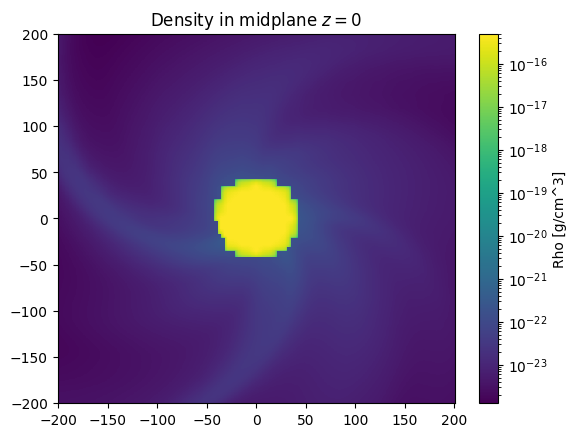

In [69]:
ih_X, ih_Y = np.meshgrid(np.linspace(-200, 200, 512), np.linspace(-200, 200, 512))
ih_Z = np.zeros_like(ih_X)
ih_rho = ih_interp(ih_X, ih_Y, ih_Z)

fig, ax = plt.subplots()
pcm = ax.pcolormesh(ih_X, ih_Y, ih_rho, norm="log")
fig.colorbar(pcm, ax=ax).set_label("Rho [g/cm^3]")
ax.set_title("Density in midplane $z=0$")
plt.show()

## Resample onto a sphere
Here the solar corona data is sampled onto a sphere.

In [60]:
_n = 360
pp, aa = np.meshgrid(
    np.linspace(0.0, np.pi, _n),
    np.linspace(0.0, 2.0 * np.pi, 2 * _n), indexing="xy")

r_sphere = 20.0
rr = r_sphere * np.ones_like(aa)

In [61]:
sphere_xyz = np.stack((
    rr * np.sin(pp) * np.cos(aa),
    rr * np.sin(pp) * np.sin(aa),
    rr * np.cos(pp)), axis=-1)

sphere_data, cell_sphere = sc_interp(sphere_xyz, return_cell_ids=True)

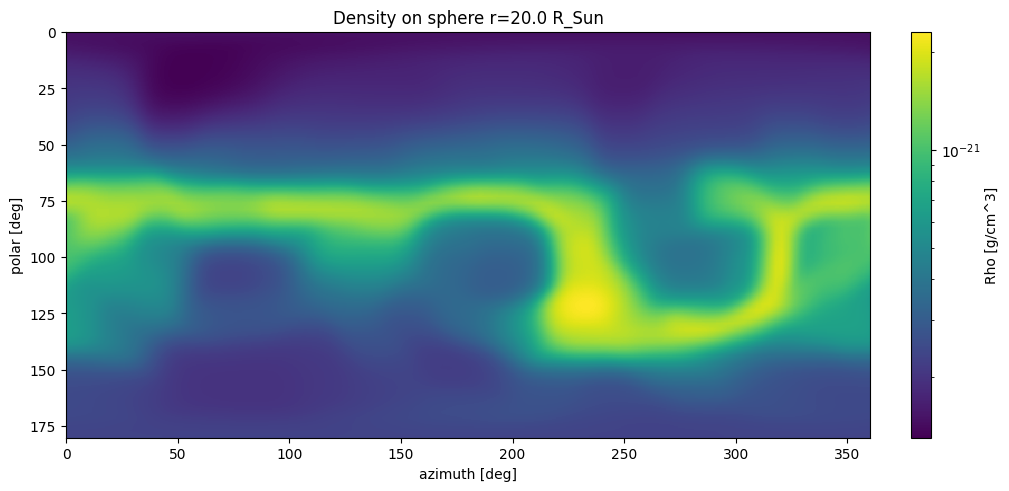

In [62]:
fig, ax = plt.subplots(figsize=(10, 4.8), constrained_layout=True)
im = ax.pcolormesh(np.degrees(aa), np.degrees(pp), sphere_data, norm="log")
ax.set_xlabel("azimuth [deg]")
ax.set_ylabel("polar [deg]")
ax.set_title(f"Density on sphere r={r_sphere} R_Sun")
cb = fig.colorbar(im, ax=ax)
cb.set_label("Rho [g/cm^3]")
ax.invert_yaxis()
plt.show()

For the inner heliosphere, we can do the same thing. We just need to make sure to use the correct octree interpolator (ih_interp instead of sc_interp) and to use a larger sphere radius.

In [63]:
r_sphere = 215.0
sphere_xyz = np.stack((
    r_sphere * np.sin(pp) * np.cos(aa),
    r_sphere * np.sin(pp) * np.sin(aa),
    r_sphere * np.cos(pp)), axis=-1)

sphere_data, cell_sphere = ih_interp(sphere_xyz, return_cell_ids=True)
sphere_data.shape

(720, 360)

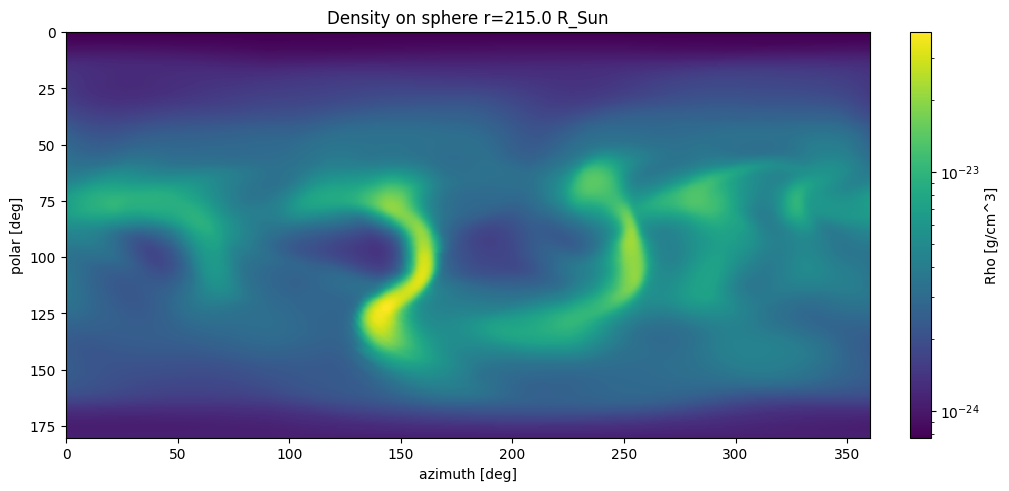

In [64]:
fig, ax = plt.subplots(figsize=(10, 4.8), constrained_layout=True)
im = ax.pcolormesh(np.degrees(aa), np.degrees(pp), sphere_data, norm="log")
ax.set_xlabel("azimuth [deg]")
ax.set_ylabel("polar [deg]")
ax.set_title(f"Density on sphere r={r_sphere} R_Sun")
cb = fig.colorbar(im, ax=ax)
cb.set_label("Rho [g/cm^3]")
ax.invert_yaxis()
plt.show()